In [11]:
import elapid
import rasterio as rio
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics
import warnings

In [12]:
# Load the data
annotation = 'src/data/annotated_1.csv'
df = pd.read_csv(annotation)
df.sample(5)

,longitude,latitude,geometry,class,easward_wind,norward_wind,sst,chla,year,month
134,-118.291398,28.883713,POINT (-118.291398 28.883713),1,156,-432,17.646700,0.135999,2014,1
25415,-118.291977,28.884160,POINT (-118.291977 28.88416),1,10,-324,18.774134,0.241308,2015,1
26974,-147.179175,42.068753,POINT (-147.179175 42.068753),1,213,698,11.071431,0.365568,2015,1
39102,-118.292023,28.884332,POINT (-118.292023 28.884332),1,10,-324,18.774134,0.241308,2015,1
32981,-123.876960,27.879327,POINT (-123.87696 27.879327),1,-240,-369,19.355112,0.079799,2015,1


In [13]:
# count the number of records per year
print(df['year'].value_counts())

year
2015    24913
2014    24016
2018    15269
Name: count, dtype: int64


In [14]:
# Seleccionar solo columnas numéricas
df.drop(columns=['class', 'month'])
numeric_columns = df.select_dtypes(include='number').columns
df_numeric = df[numeric_columns]
df_numeric.drop(columns=['year', 'month', 'class', ], inplace=True)


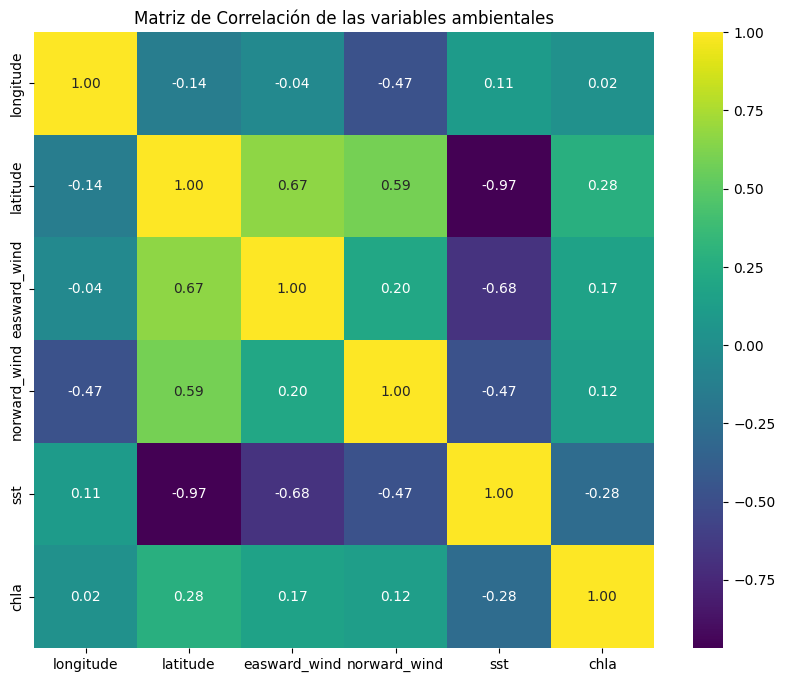

In [16]:
import seaborn as sns
# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f')
plt.title('Matriz de Correlación de las variables ambientales')
plt.show()


In [15]:
# Train-test split.

train_df = df[df['year'] < 2018]
test_df = df[df['year'] == 2018]

# Separar características (X) y objetivo (y)
cols_to_drop = ['class', 'month', 'year', 'geometry', 'longitude', 'latitude']
X_train_full = train_df.drop(columns=cols_to_drop)
y_train_full = train_df['class']

X_test = test_df.drop(columns=cols_to_drop)
y_test = test_df['class']

# Dividir el conjunto de entrenamiento en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)


In [17]:
# Entrenar el modelo
model = elapid.MaxentModel(transform='cloglog', beta_multiplier=2.0)

# Medir el tiempo de entrenamiento
import time
start_time = time.time()

model.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f"Tiempo de entrenamiento: {elapsed_time:.2f} segundos")

Tiempo de entrenamiento: 229.02 segundos


In [18]:
# Validar el modelo
y_val_pred = model.predict(X_val)
val_accuracy = metrics.roc_auc_score(y_val, y_val_pred)
print(f'Validation AUC: {val_accuracy:.3f}')


Validation AUC: 0.970


In [19]:
import os
os.makedirs('src/models', exist_ok=True)
elapid.save_object(model, 'src/models/maxent_model_enero.pkl')

In [20]:
# Evaluar el modelo en el conjunto de prueba
y_test_pred = model.predict(X_test)
test_accuracy = metrics.roc_auc_score(y_test, y_test_pred)
print(f'Test AUC: {test_accuracy:.3f}')

Test AUC: 0.886


In [21]:
from src.sample_raster_data import get_rasters_list
output_raster = 'src/models/predictions_enero.tif'
rasters, labels = get_rasters_list(year=2018, month=str(1).zfill(2))

In [22]:
elapid.apply_model_to_rasters(model, rasters, output_raster, quiet=True)

# and read into memory
with rio.open(output_raster, 'r') as src:
    pred = src.read(1, masked=True)

In [41]:
# Load prediction raster
with rio.open(output_raster) as src:
    # Set CRS to EPSG:4326
    pred = src.read(1, masked=True)
    pred = pred.astype(float)
    pred[pred == src.nodata] = 0
    
    
   
# Plot the original and predicted rasters
fig, axs = plt.subplots(1, 1, figsize=(12, 6))
axs.imshow(pred, cmap='viridis')
axs.set_title('Predicted distribution for January 2018')
# Bar with color scale
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'))
# Remove axes
axs.axis('off')
plt.show()


NameError: name 'rio' is not defined